In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
losses = pd.read_csv("./monthly_losses_data.csv")
mortality = pd.read_csv("./monthly_mortality_data.csv")

In [4]:
losses.head(5)

,species,date,geo_group,region,losses,dead,discarded,escaped,other
0,salmon,2020-01-01,area,1,31425,28126,3299,0,0
1,salmon,2020-01-01,area,2,324116,277888,46113,0,115
2,salmon,2020-01-01,area,3,844829,776983,63770,0,4076
3,salmon,2020-01-01,area,4,676852,623159,51823,0,1870
4,salmon,2020-01-01,area,5,109269,97627,11424,0,218


In [5]:
mortality.head(5)

,species,date,geo_group,region,median,q1,q3
0,rainbowtrout,2020-01-01,area,4,0.63,0.34,1.00
1,rainbowtrout,2020-02-01,area,4,0.60,0.41,1.17
2,rainbowtrout,2020-03-01,area,4,0.74,0.40,1.64
3,rainbowtrout,2020-04-01,area,4,0.51,0.19,1.59
4,rainbowtrout,2020-05-01,area,4,0.49,0.25,1.56


In [6]:
losses['species'].unique()

<StringArray>
['salmon', 'rainbowtrout']
Length: 2, dtype: str

In [7]:
mortality['species'].unique()

<StringArray>
['rainbowtrout', 'salmon']
Length: 2, dtype: str

In [8]:
losses["geo_group"].unique()

<StringArray>
['area', 'county', 'country']
Length: 3, dtype: str

In [9]:
losses['region'].unique()

<StringArray>
[              '1',               '2',               '3',               '4',
               '5',               '6',               '7',               '8',
               '9',              '10',              '11',              '12',
              '13',           'Agder',        'Rogaland',        'Vestland',
 'Møre og Romsdal',       'Trøndelag',        'Nordland',           'Troms',
        'Finnmark',        'Akershus',           'Norge']
Length: 23, dtype: str

In [21]:
losses.groupby("geo_group").agg({"region": "unique"})

,region
geo_group,
area,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13]"
country,[Norge]
county,"[Agder, Rogaland, Vestland, Møre og Romsdal, T..."


In [49]:
mortality['month'] = pd.DatetimeIndex(mortality['date']).month

In [50]:
mortality

,species,date,geo_group,region,median,q1,q3,month
0,rainbowtrout,2020-01-01,area,4,0.63,0.34,1.00,1
1,rainbowtrout,2020-02-01,area,4,0.60,0.41,1.17,2
2,rainbowtrout,2020-03-01,area,4,0.74,0.40,1.64,3
3,rainbowtrout,2020-04-01,area,4,0.51,0.19,1.59,4
4,rainbowtrout,2020-05-01,area,4,0.49,0.25,1.56,5
...,...,...,...,...,...,...,...,...
1783,salmon,2025-08-01,county,Finnmark,0.30,0.17,0.55,8
1784,salmon,2025-09-01,county,Finnmark,0.37,0.27,0.57,9
1785,salmon,2025-10-01,county,Finnmark,0.43,0.23,0.86,10
1786,salmon,2025-11-01,county,Finnmark,0.32,0.19,0.48,11


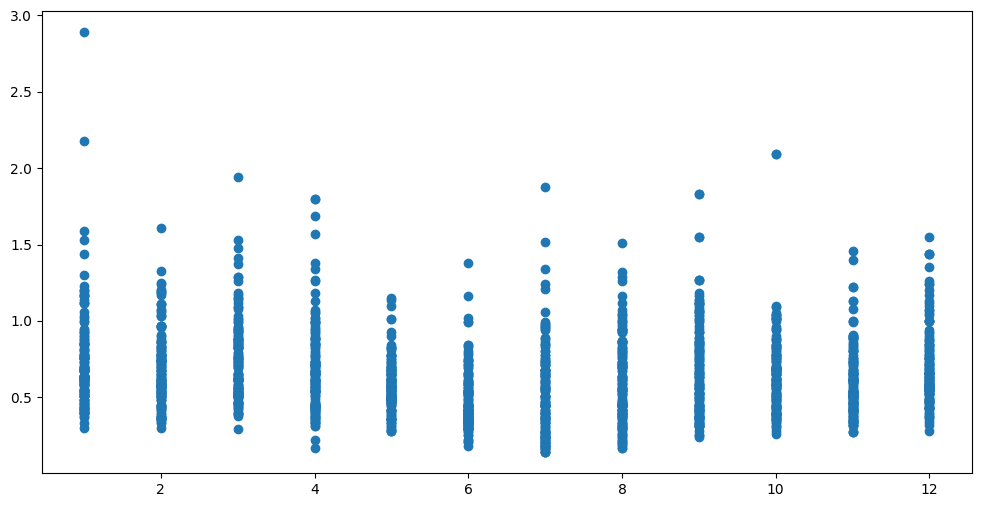

In [51]:
plt.figure(figsize=(12, 6))
plt.scatter(mortality.month, mortality['median'])

In [28]:
mortality.info()

<class 'pandas.DataFrame'>
RangeIndex: 1788 entries, 0 to 1787
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   species    1788 non-null   str    
 1   date       1788 non-null   str    
 2   geo_group  1788 non-null   str    
 3   region     1788 non-null   str    
 4   median     1788 non-null   float64
 5   q1         1788 non-null   float64
 6   q3         1788 non-null   float64
dtypes: float64(3), str(4)
memory usage: 97.9 KB


In [29]:
mortality['date'] = pd.to_datetime(mortality['date'])

In [39]:
pd.DatetimeIndex(mortality['date']).month

Index([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10,
       ...
        3,  4,  5,  6,  7,  8,  9, 10, 11, 12],
      dtype='int32', name='date', length=1788)

<Axes: xlabel='region'>

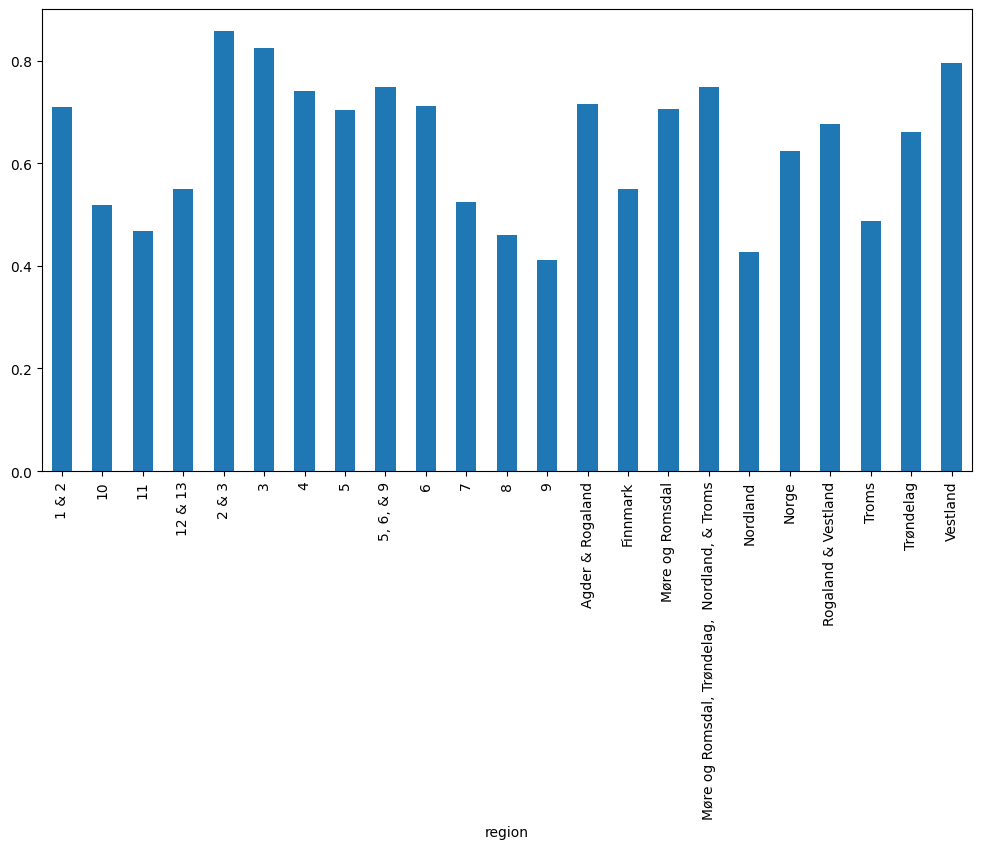

In [53]:
plt.figure(figsize=(12, 6))

mortality.groupby('region')['median'].mean().plot(kind="bar")
